## Import libraries

In [33]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

## Read csv

In [34]:
primary_df = pd.read_csv("dream.csv", usecols=list(range(1, 22)), header=0, names=["nick",
                                                                 "age",
                                                                 "sex", 
                                                                 "agreement", 
                                                                 "date",
                                                                 "fall_asleep",
                                                                 "wake_up", 
                                                                 "sleep_quality", 
                                                                 "awakenings", 
                                                                 "dream_target", 
                                                                 "dream_color", 
                                                                 "amount_of_coffee", 
                                                                 "amount_of_coffee_after16",
                                                                 "alcohol",
                                                                 "strong_emotions",
                                                                 "stress_level",
                                                                 "hours_of_physical_activity",
                                                                 "daytime_sleep",
                                                                 "food_before_bed",
                                                                 "screen_time",
                                                                 "screen_before_bed",
                                                                 ])
primary_df.head(5)

,nick,age,sex,agreement,date,fall_asleep,wake_up,sleep_quality,awakenings,dream_target,...,amount_of_coffee,amount_of_coffee_after16,alcohol,strong_emotions,stress_level,hours_of_physical_activity,daytime_sleep,food_before_bed,screen_time,screen_before_bed
0,OLKA75,45 лет и более,Женский,Да,13.09.2026,23:30:00,6:45:00,3,3,Да,...,1,0,Да,Нет,4,2,Да,Нет,3,Да
1,Zverskiyponos67,до 18 лет,Женский,Да,13.09.2026,2:00:00,10:00:00,3,1,Нет,...,1,0,Нет,Нет,5,0,Нет,Нет,8,Нет
2,Kreeper,от 18 до 30 лет,Женский,Да,13.09.2026,0:00:00,8:13:00,4,0,Нет,...,0,0,Нет,Нет,2,4,Нет,Нет,8,Да
3,Tukiceja,45 лет и более,Мужской,Да,13.09.2026,23:00:00,6:20:00,3,3,Нет,...,1,0,Да,Нет,2,3,Да,Нет,3,Да
4,TihiyOmut,от 18 до 30 лет,Мужской,Да,13.09.2026,3:00:00,10:25:00,5,0,Да,...,10,4,Да,Да,2,1,Нет,Да,3,Да


Значение столбцов:
- id - ник пользователей
- age - возраст
- sex - пол
- agreement - соглашение на обработку персональных даных
- date - дата заполнения
- fall_asleep - время засыпания
- wake_up - время пробуждения
- sleep_quality - оценка качества сна (1-5)
- awakenings - количество пробуждений ночью (1-10)
- dream_target - запомнился ли сон (Да/Нет)
- dream_color - цвет сна (Цветной/Чёрно-белый/Точно не могу сказать)
- amount_of_coffee - количество чашек кофе (0-10)
- amount_of_coffee_after16 - количество чашек кофе после 16 (0-10)
- alcohol - употребление алкоголя (Да/Нет)
- strong_emotions - сильные эмоции (Да/Нет)
- stress_level - уровень стресса (1-10)
- hours_of_physical_activity - часы физической активности (0-10)
- daytime_sleep - сон днём (Да/Нет)
- food_before_bed - еда перед сном (Да/Нет)
- screen_time - экранное время за день (0-10)
- screen_before_bed - экран перед сном (Да/Нет)

## General EDA

In [35]:
print(f"Размер dataframe: {primary_df.shape}")

Размер dataframe: (421, 21)


In [36]:
primary_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421 entries, 0 to 420
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   nick                        421 non-null    str  
 1   age                         421 non-null    str  
 2   sex                         421 non-null    str  
 3   agreement                   421 non-null    str  
 4   date                        421 non-null    str  
 5   fall_asleep                 421 non-null    str  
 6   wake_up                     421 non-null    str  
 7   sleep_quality               421 non-null    int64
 8   awakenings                  421 non-null    int64
 9   dream_target                421 non-null    str  
 10  dream_color                 187 non-null    str  
 11  amount_of_coffee            421 non-null    int64
 12  amount_of_coffee_after16    421 non-null    int64
 13  alcohol                     421 non-null    str  
 14  strong_emotions      

In [37]:
df = primary_df.copy()

### Downcast features and conversion to categorical form

In [38]:
# Дата
df["date"] = pd.to_datetime(df["date"])

# Время
df["wake_up"] = pd.to_timedelta(df["wake_up"])
df["fall_asleep"] = pd.to_timedelta(df["fall_asleep"])

# Категориальные колонки
df["dream_color"] = df["dream_color"].map({"В основном цветное": "color", "В основном чёрно-белое": "black-white", "Точно не могу сказать": "not_defined"})
categorial_cols = ["dream_color"]
df[categorial_cols] = df[categorial_cols].astype("category")

age_ordered = ["до 18 лет", "от 18 до 30 лет", "от 30 до 45  лет", "45 лет и более"]
df["age"] = pd.Categorical(df["age"], categories=age_ordered, ordered=True)

# Кодировка и преобразование в числовые
df["sex"] = df["sex"].map({"Мужской": 0, "Женский": 1})

binar_dict = {"Нет": 0, "Да": 1}
binary_cols = ["dream_target", "alcohol", "daytime_sleep", "food_before_bed", "strong_emotions", "screen_before_bed"]
for col in binary_cols:
    df[col] = df[col].map(binar_dict)
    
for col in df.columns:
    if "int" in str(df[col].dtype):
        df[col] = pd.to_numeric(df[col], downcast="integer")

C:\Users\Ilay\AppData\Local\Temp\ipykernel_14572\2291119382.py:2: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"])


In [39]:
print("Пропусков после бинаризации:", df[binary_cols].isna().sum().sum())

Пропусков после бинаризации: 0


In [40]:
df = df.drop(["agreement"], axis=1)

In [41]:
# info после обработки столбцов
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421 entries, 0 to 420
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype          
---  ------                      --------------  -----          
 0   nick                        421 non-null    str            
 1   age                         421 non-null    category       
 2   sex                         421 non-null    int8           
 3   date                        421 non-null    datetime64[us] 
 4   fall_asleep                 421 non-null    timedelta64[us]
 5   wake_up                     421 non-null    timedelta64[us]
 6   sleep_quality               421 non-null    int8           
 7   awakenings                  421 non-null    int8           
 8   dream_target                421 non-null    int8           
 9   dream_color                 187 non-null    category       
 10  amount_of_coffee            421 non-null    int8           
 11  amount_of_coffee_after16    421 non-null    int8        

In [42]:
df.describe()

,sex,date,fall_asleep,wake_up,sleep_quality,awakenings,dream_target,amount_of_coffee,amount_of_coffee_after16,alcohol,strong_emotions,stress_level,hours_of_physical_activity,daytime_sleep,food_before_bed,screen_time,screen_before_bed
count,421.000000,421,421,421,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000,421.000000
mean,0.646081,2026-09-18 15:30:21.377672,0 days 09:48:17.529691,0 days 07:51:21.092636,3.745843,1.268409,0.444181,0.790974,0.263658,0.097387,0.451306,3.634204,2.524941,0.128266,0.460808,5.529691,0.909739
min,0.000000,2026-09-13 00:00:00,0 days 00:00:00,0 days 00:09:00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2026-09-16 00:00:00,0 days 01:00:00,0 days 06:30:00,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000,3.000000,1.000000
50%,1.000000,2026-09-19 00:00:00,0 days 02:50:00,0 days 07:40:00,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,2.000000,0.000000,0.000000,5.000000,1.000000
75%,1.000000,2026-09-22 00:00:00,0 days 23:00:00,0 days 09:00:00,5.000000,2.000000,1.000000,1.000000,0.000000,0.000000,1.000000,5.000000,4.000000,0.000000,1.000000,8.000000,1.000000
max,1.000000,2026-09-26 00:00:00,0 days 23:59:00,0 days 16:12:00,5.000000,10.000000,1.000000,10.000000,4.000000,1.000000,1.000000,10.000000,10.000000,1.000000,1.000000,10.000000,1.000000
std,0.478753,NaN,0 days 10:23:36.991220,0 days 01:54:55.151073,1.068828,1.653762,0.497466,1.118679,0.568486,0.296837,0.498215,2.294749,1.997015,0.334784,0.499055,2.692529,0.286897


Невалидные данные отсутствуют. Среднее значение превышает медиану из-за наличия в столбце смещения в сторону больших значений

In [43]:
df.isna().sum()

nick                            0
age                             0
sex                             0
date                            0
fall_asleep                     0
wake_up                         0
sleep_quality                   0
awakenings                      0
dream_target                    0
dream_color                   234
amount_of_coffee                0
amount_of_coffee_after16        0
alcohol                         0
strong_emotions                 0
stress_level                    0
hours_of_physical_activity      0
daytime_sleep                   0
food_before_bed                 0
screen_time                     0
screen_before_bed               0
dtype: int64

In [44]:
without_dream = df[df["dream_target"]== 0]["dream_target"].count()
print(f"Количество ответов людей, не видивших сон: {without_dream}")

Количество ответов людей, не видивших сон: 234


Пропуски найдены только в столбце dream_color: 233 из-за того, что лоди ночью не видели сон - технические пропуски

In [45]:
df.duplicated().sum()

np.int64(0)

Дупликатов не найдено

In [46]:
df.nunique()

nick                           53
age                             4
sex                             2
date                           14
fall_asleep                   117
wake_up                       118
sleep_quality                   5
awakenings                     11
dream_target                    2
dream_color                     3
amount_of_coffee                6
amount_of_coffee_after16        4
alcohol                         2
strong_emotions                 2
stress_level                   10
hours_of_physical_activity     10
daytime_sleep                   2
food_before_bed                 2
screen_time                    11
screen_before_bed               2
dtype: int64

### Analysis of users who completed the survey

In [47]:
df["nick"].unique()

<StringArray>
[          'OLKA75',  'Zverskiyponos67',          'Kreeper',
         'Tukiceja',        'TihiyOmut',         'aboba777',
      'SLEEP_LOVER',            'hewwa',            'Прага',
              'Оно',           'nejnej',         'krasotka',
            'FOX07',             'Leva',         'Удача777',
          '1515net',      'Птицадивная',       'nikita_pdf',
    'Enemyofdeath ',        'aquamana ',          'GRASS42',
          'Маркул ',       'Константин',           'Наташа',
              'son',    'Питер Паркер ',       'silverain ',
 'GangsterMarmilad',         'WH1teM4N',            'Настя',
          'Rinasvm',           'Deston',            'груша',
        'даринкинс',     'Enemyofdeath',               'N1',
           'Fit345',        'Tukiceja ',     'Питер Паркер',
         'aquamana',           'Маркул',     'Птицадивная ',
        'silverain',       'TihiyOmut ',          'Pandora',
        'WH1teM4N ',      'nikita_pdf ',       'Sunflower ',
        'S

In [48]:
df["nick"] = df["nick"].str.replace(" ", "").str.strip()
print(f"Количество уникальных пользователей: {df["nick"].nunique()}")

Количество уникальных пользователей: 38


In [49]:
person_day = df.groupby(by=["nick"]).size().reset_index(name='count')
person_day

,nick,count
0,1515net,12
1,Deston,4
2,Enemyofdeath,12
3,FOX07,12
4,Fit345,11
5,GRASS42,12
6,GangsterMarmilad,12
7,Kreeper,12
8,Leva,12
9,N1,7


In [50]:
print(f"Количество участников, проходивших опрос все 12 дней: {len(person_day[person_day["count"] >= 12])}")

Количество участников, проходивших опрос все 12 дней: 26


In [51]:
df["id"] = df.groupby(by=["nick"])["nick"].transform("ngroup") + 1

In [52]:
df[["id", "age"]].drop_duplicates()["age"].value_counts(normalize=True)

age
от 18 до 30 лет     0.692308
45 лет и более      0.205128
до 18 лет           0.076923
от 30 до 45  лет    0.025641
Name: proportion, dtype: float64

Возраст 69% в группе "от 18 до 30 лет", признак почти константа

In [53]:
df[["id", "sex"]].drop_duplicates()["sex"].value_counts(normalize=True)

sex
1    0.657895
0    0.342105
Name: proportion, dtype: float64

In [54]:
# Подсчёт продолжительности сна
diff = df["wake_up"] - df["fall_asleep"]
mask = diff < pd.Timedelta(0)
diff.loc[mask] += pd.Timedelta(days=1)

df["sleep_duration"] = diff
df["sleep_hours"] = diff.dt.total_seconds() / 3600

## Analysis of the target variable `dream_target` with each feature

In [55]:
df["dream_target"].value_counts(normalize=True)

dream_target
0    0.555819
1    0.444181
Name: proportion, dtype: float64

In [56]:
df.groupby(by="id")["dream_target"].mean().sort_values()

id
5     0.000000
12    0.000000
1     0.166667
21    0.166667
28    0.166667
38    0.166667
20    0.181818
19    0.250000
32    0.250000
2     0.250000
37    0.272727
22    0.272727
10    0.285714
34    0.333333
26    0.333333
15    0.375000
30    0.384615
9     0.416667
7     0.416667
3     0.416667
16    0.454545
6     0.500000
29    0.500000
18    0.500000
35    0.500000
14    0.545455
31    0.571429
13    0.571429
33    0.583333
36    0.636364
24    0.666667
23    0.666667
17    0.666667
8     0.666667
25    0.666667
27    0.666667
11    0.833333
4     0.916667
Name: dream_target, dtype: float64

In [57]:
df["dream_color"].value_counts(normalize=True)

dream_color
color          0.802139
not_defined    0.133690
black-white    0.064171
Name: proportion, dtype: float64

In [58]:
dream_color_for_ages = df.groupby(by="age")["dream_color"].value_counts().reset_index(name="count")
pivot_dream_color = dream_color_for_ages.pivot(index="age", columns="dream_color", values="count")
pivot_dream_color

dream_color,black-white,color,not_defined
age,,,
до 18 лет,0,4,0
от 18 до 30 лет,2,112,11
от 30 до 45 лет,0,7,0
45 лет и более,10,27,14


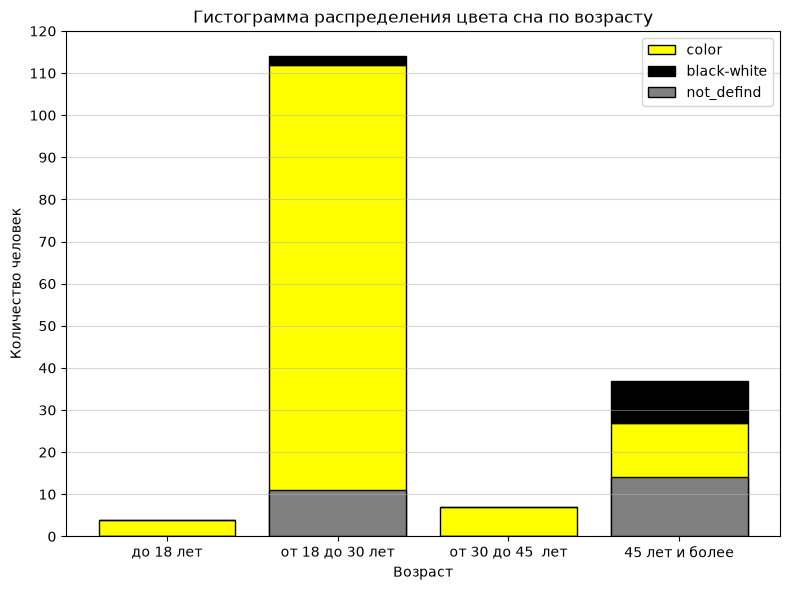

In [59]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(pivot_dream_color.index, pivot_dream_color["color"], color="yellow", edgecolor="black")
ax.bar(pivot_dream_color.index, pivot_dream_color["black-white"], bottom=pivot_dream_color["color"], color="black", edgecolor="black")
ax.bar(pivot_dream_color.index, pivot_dream_color["not_defined"], color="gray", edgecolor="black")

ax.set_title("Гистограмма распределения цвета сна по возрасту")
ax.set_xlabel("Возраст")
ax.set_ylabel("Количество человек")

ax.set_yticks(range(0, 130, 10))

ax.grid(True, axis="y", alpha=0.5)

ax.legend(labels=["color", "black-white", "not_defind"])

plt.tight_layout()
plt.show()

Более 80% людей видят цветной сон, чёрно-белый сон в основном видят только люди возрастом более 45 лет (возможная причина - жизнь в период чёрно-белого телевидения/фотографии). Из-за небольшой выборки dream_color сложно рассматривать как целевой признак

### Creating a boxplot for the target variable `dream_target` for all individuals.

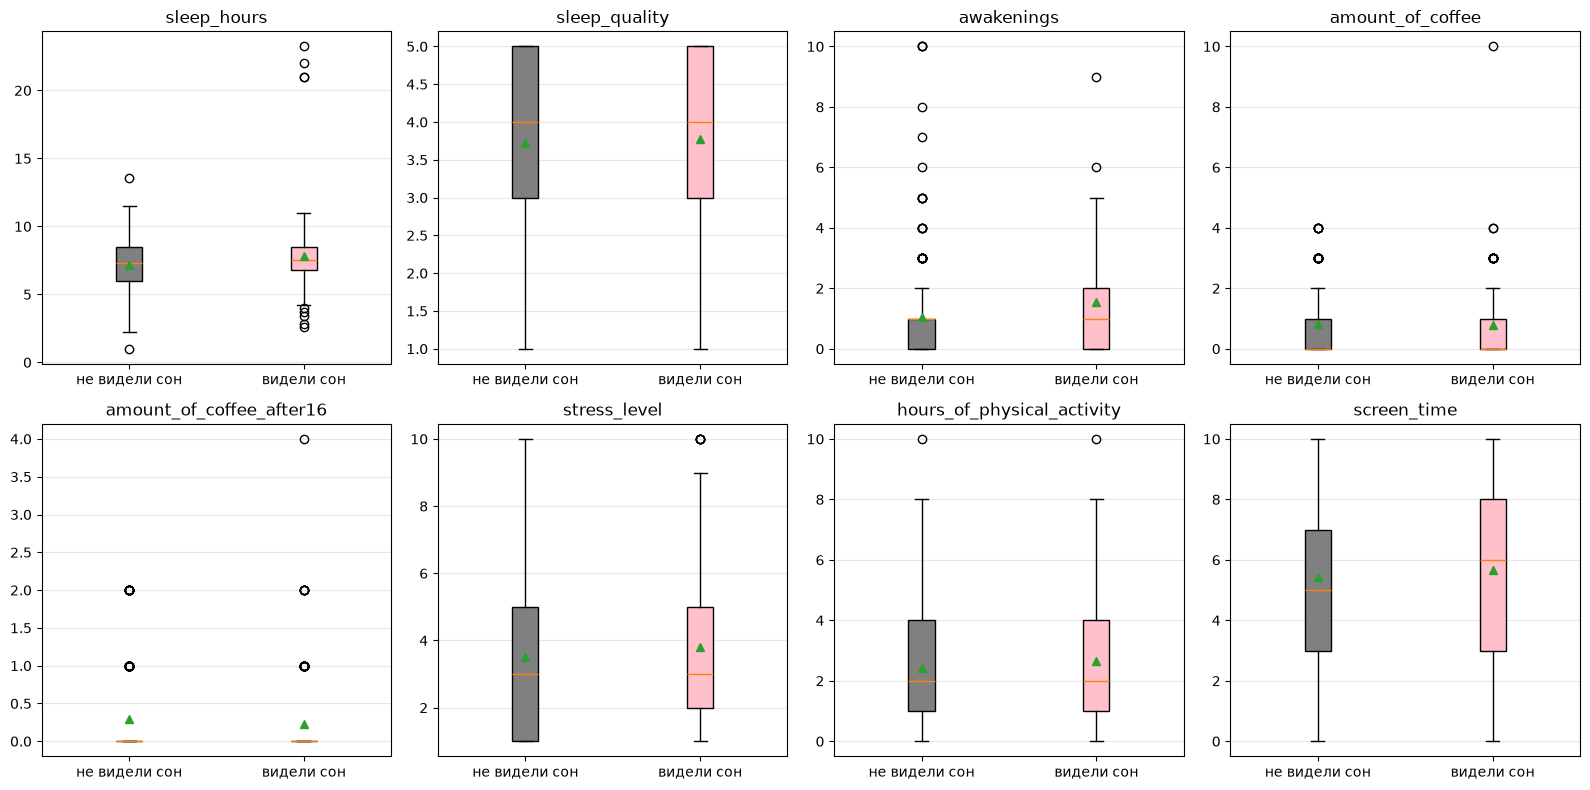

In [60]:
boxplot_cols = ['sleep_hours', 'sleep_quality', 'awakenings', 'amount_of_coffee', 'amount_of_coffee_after16', 'stress_level', 'hours_of_physical_activity', 'screen_time']

n = len(boxplot_cols)

fig, axes =  plt.subplots(2, (n + 1) // 2, figsize=(4 * ((n + 1) // 2), 8))

for ax, i in zip(axes.flatten(), boxplot_cols):

    group_0 = df[df["dream_target"] == 0][i].values
    group_1 = df[df["dream_target"] == 1][i].values

    bp = ax.boxplot([group_0, group_1], tick_labels=["не видели сон", "видели сон"], showmeans=True, patch_artist=True)

    ax.set_title(f"{i}", fontsize=12)

    ax.grid(True, alpha=0.3, axis="y")

    bp["boxes"][0].set_facecolor("gray")
    bp["boxes"][1].set_facecolor("pink")

plt.tight_layout()
plt.show()

- sleep hours: Медиана у видевших сон немного выше - примерно 7,5 часа против 7–7,2 часа. Есть выбросы около 21–23 часов; их стоит проверить в исходных данных.
- awakenings: У видевших и невидевших сон медиана около 1 пробуждения. Разброс большой, много выбросов сверху, у людей не видевших сон
- stress_level: Медиана в обеих группах около 3. У видевших сон среднее выглядит немного выше, но распределения существенно перекрываются.
- screen_time: Медиана у видевших сон около 6 часов, у не видевших — около 5. При этом разброс в обеих группах широк
- в графиках sleep_quality, amount_of_coffe(_after16), hours_of_physical_activity между видевшими и невидевшими сон различия близки к минимуму

### Creating a barchart for the target variable `dream_target` for all individuals.

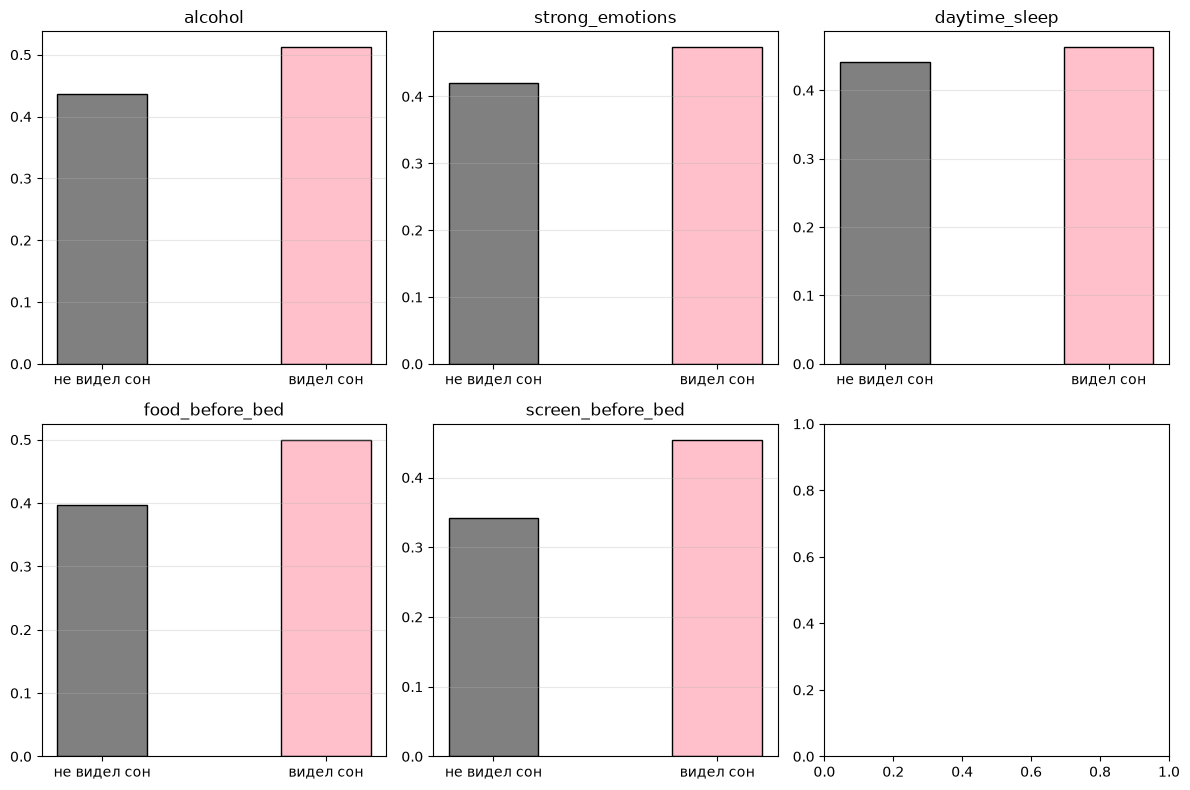

In [61]:
barchart_cols = ["alcohol", "strong_emotions", "daytime_sleep", "food_before_bed", "screen_before_bed"]

n = len(barchart_cols)

fig, axes =  plt.subplots(2, (n + 1) // 2, figsize=(4 * ((n + 1) // 2), 8))

for ax, i in zip(axes.flatten(), barchart_cols):
    
    grouped = df.groupby(i)["dream_target"].mean()
    
    grouped.index = ["не видел сон", "видел сон"]
    ax.bar(grouped.index, grouped, color=["gray", "pink"], width=0.4, edgecolor="black")

    ax.set_title(f"{i}", fontsize=12)

    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

- alcohol: Доля несколько выше среди видевших сон
- strong_emotions: Разница незначительная
- daytime_sleep: Практически одинаковые доли
- food_before_bed: Разница около 10 процентных пунктов — одна из наиболее заметных на этих графиках
- screen_before_bed: Разница около 11 процентных пунктов — также одна из наиболее заметных

## Create a correlation matrix

In [62]:
num_cols = df.select_dtypes(include=[np.number], exclude=[np.timedelta64])
num_cols

,sex,sleep_quality,awakenings,dream_target,amount_of_coffee,amount_of_coffee_after16,alcohol,strong_emotions,stress_level,hours_of_physical_activity,daytime_sleep,food_before_bed,screen_time,screen_before_bed,id,sleep_hours
0,1,3,3,1,1,0,1,0,4,2,1,0,3,1,11,7.250000
1,1,3,1,0,1,0,0,0,5,0,0,0,8,0,19,8.000000
2,1,4,0,0,0,0,0,0,2,4,0,0,8,1,8,8.216667
3,0,3,3,0,1,0,1,0,2,3,1,0,3,1,17,7.333333
4,0,5,0,1,10,4,1,1,2,1,0,1,3,1,16,7.416667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
416,1,5,0,0,0,0,0,0,2,1,0,0,8,1,37,8.333333
417,1,5,0,0,0,0,0,0,1,0,0,1,7,1,37,6.833333
418,1,4,4,0,1,0,0,0,3,0,0,0,3,1,35,8.666667
419,1,4,3,1,2,0,0,1,3,3,0,0,1,0,31,7.866667


In [63]:
corr_matrix = num_cols.corr()

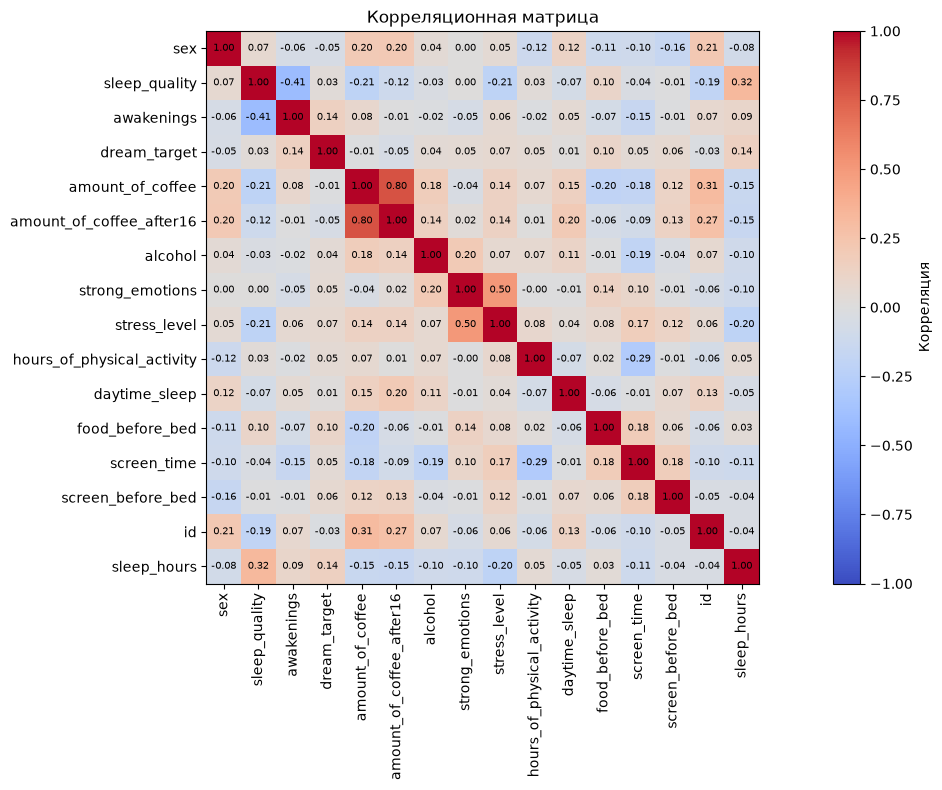

In [64]:
fig, ax = plt.subplots(figsize=(15, 8))

im = ax.imshow(corr_matrix, vmin=-1, vmax=1, cmap="coolwarm")

ax.set_title("Корреляционная матрица")
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_yticklabels(corr_matrix.columns, fontsize=10, rotation=0)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, fontsize=10, rotation=90)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f"{val:.2f}",  ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax, label="Корреляция")

plt.tight_layout()
plt.show()

Прямой линейной корреляции с целевой переменной dream_target не обнаружено

## Panel EDA